In [2]:
# =========================
# System / Utilities
# =========================
import os
import re
import tempfile
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")  # keep notebook output tidy

# =========================
# Data / Plotting
# =========================
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Data Access (optional)
# =========================
try:
    import yfinance as yf
except Exception:
    yf = None

try:
    from pandas_datareader import data as web
except Exception:
    web = None

# =========================
# ML: Models, Metrics, CV
# =========================
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from scipy.stats import pearsonr

# =========================
# Time-Series / Stats
# =========================
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================
# Imbalanced Data (optional)
# =========================
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None

# =========================
# Explainability (optional)
# =========================
try:
    import shap
except Exception:
    shap = None

# =========================
# NLP: FinBERT (optional)
# =========================
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # reduce tokenizer thread warnings
try:
    import torch
    import torch.nn.functional as F
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
except Exception:
    torch = None
    F = None
    AutoModelForSequenceClassification = None
    AutoTokenizer = None

# =========================
# Scraping / PDF (optional)
# =========================
try:
    import requests
except Exception:
    requests = None

try:
    import pdfplumber
except Exception:
    pdfplumber = None

try:
    from bs4 import BeautifulSoup
except Exception:
    BeautifulSoup = None

# =========================
# Notebook display helpers
# =========================
from IPython.display import Markdown, display

In [3]:
# Claim all the folders used
project_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject"
scripts_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Scripts"
macro_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro"
beigebook_directory = "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/beigebook"
model_directory =     "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Models"
results_directory =   "/Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Results"

Saved backward-looking dataset to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/macro_final_bl_df.csv  
Saved forward-looking dataset to: /Users/rick/Desktop/PhD/Courses/09_Praxis_Research_SEAS_8588_DA3/Porject/Data/macro/macro_final_fl_df.csv

In [64]:
# # Read the CSV into a DataFrame
# macro_regime_labeled_path = os.path.join(macro_directory, "macro_full_df_clean.csv")
# macro_df = pd.read_csv(macro_regime_labeled_path, index_col=0, parse_dates=True)

# # Confirm successful load
# print(macro_df.info())
# print(macro_df.head(2))
# print(macro_df.tail(2))

In [7]:
# Read the CSV into a DataFrame
macro_fl_path = os.path.join(macro_directory, "macro_final_fl_df.csv")
macro_fl_df = pd.read_csv(macro_fl_path, index_col=0, parse_dates=True)

# Confirm successful load
print(macro_fl_df.info())
print(macro_fl_df.head(2))
print(macro_fl_df.tail(2))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2003-01-01 to 2023-08-01
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CPI                        248 non-null    float64
 1   INDPRO                     248 non-null    float64
 2   VIX                        248 non-null    float64
 3   T10YIE                     248 non-null    float64
 4   GS10                       248 non-null    float64
 5   SP500                      248 non-null    float64
 6   TLT                        248 non-null    float64
 7   Inflation_Uncertainty_10y  248 non-null    float64
 8   Inflation_10y              248 non-null    float64
 9   Real_Yield_10y             248 non-null    float64
 10  INDPRO_YoY_Growth          248 non-null    float64
 11  SP500_TLT_Corr_24m_fl      248 non-null    float64
dtypes: float64(12)
memory usage: 25.2 KB
None
              CPI   INDPRO        VIX    T10Y

# Gradient Boosting Forecasting Pipeline Summary

This notebook describes a machine learning pipeline built to forecast the **24-month forward-looking correlation** between the S&P 500 and TLT using macroeconomic features, following Wu et al.'s methodology.

---

## Step 1: Data Preparation

- **Source**: `macro_fl_df` DataFrame containing macroeconomic time series.
- **Features used** (Wu’s 5-factor inputs):
  - `Inflation_10y`
  - `Inflation_Uncertainty_10y`
  - `Real_Yield_10y`
  - `VIX`
  - `INDPRO_YoY_Growth`
- **Target**:  
  - `SP500_TLT_Corr_24m_fl` (24-month forward-looking rolling correlation).
  - Created using `.shift(-23)` to forecast future correlation.

---

## Step 2: Chronological Train-Test Split

- Performs an **80/20 time-based split**:
  - Training set: First 80% of the time series.
  - Test set: Final 20% of the series.
- Ensures temporal order is maintained (important for time series).

---

## Step 3: Pipeline + Grid Search

- **Pipeline Components**:
  - `StandardScaler()` – standardizes features.
  - `GradientBoostingRegressor()` – regression model.
  
- **Hyperparameter Tuning**:
  - Performed using `GridSearchCV` with `TimeSeriesSplit` (`n_splits=5`).
  - Search space:
    - `n_estimators`: [50, 100, 200, 300]
    - `learning_rate`: [0.01, 0.05, 0.1, 0.2]
    - `max_depth`: [2, 3, 4, 5]
    - `subsample`: [0.8, 0.9, 1.0]
  - **Scoring metric**: Negative Mean Squared Error (MSE)

---

## Step 4: Evaluation

- **Best model** selected from grid search.
- Performance metric: **Root Mean Squared Error (RMSE)** on the test set.
- Output includes:
  - Best hyperparameters
  - Final RMSE of the selected model

---

## Step 5: Visualization

- **Plot** of predicted vs. actual 24-month correlations over time:
  - Red dashed line: Predicted values
  - Blue line: Actual values
- Aimed to visually evaluate model fit and detect regime shifts.

---

## Benchmark Reference

- **Paper’s benchmark RMSE**: `0.1307`
- Use this as a performance comparison target.

---

Best hyperparameters found: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 4, 'regressor__n_estimators': 50, 'regressor__subsample': 1.0}
Final Model RMSE with best hyperparameters: 0.4926


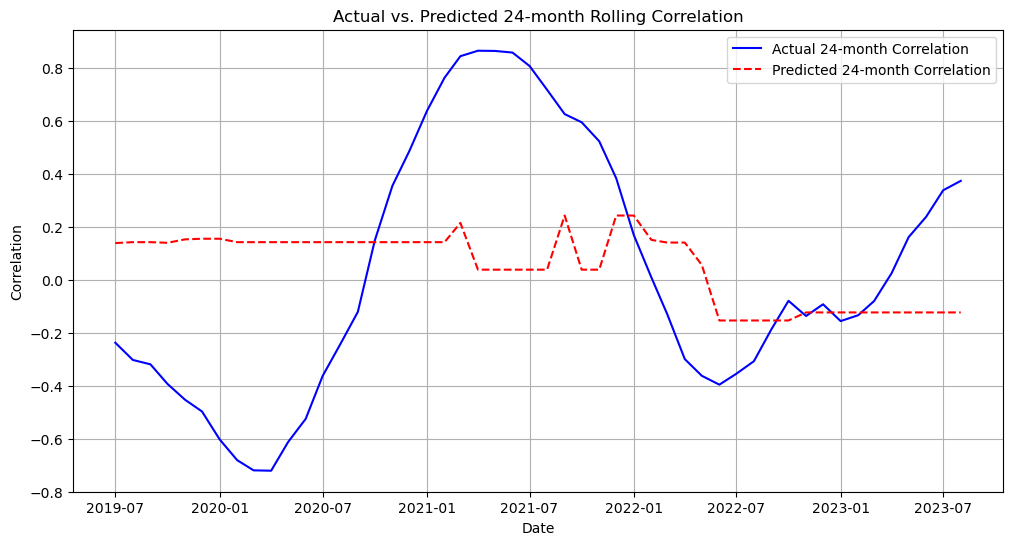

Paper's benchmark RMSE: 0.1307


In [17]:
# --- Step 1: Prepare Data ---
df = macro_fl_df.copy()

# Define Wu’s five final input features
features = [
    'Inflation_10y',
    'Inflation_Uncertainty_10y',
    'Real_Yield_10y',
    'VIX',
    'INDPRO_YoY_Growth'
]

# Target variable: 24-month forward-looking rolling correlation
X = df[features]
y = df['SP500_TLT_Corr_24m_fl']  # Make sure this was created with `.shift(-23)` earlier

# Drop rows with missing values (due to shifting or data issues)
X = X.dropna()
y = y.loc[X.index]

# --- Step 2: Chronological 80/20 Split ---
split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# --- Step 3: Pipeline and Hyperparameter Tuning ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_depth': [2, 3, 4, 5],
    'regressor__subsample': [0.8, 0.9, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# --- Step 4: Evaluation ---
best_pipeline = grid_search.best_estimator_
print("Best hyperparameters found:", grid_search.best_params_)

y_pred = best_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final Model RMSE with best hyperparameters: {rmse:.4f}")

# --- Step 5: Visualization ---
test_dates = X_test.index

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test, label='Actual 24-month Correlation', color='blue')
plt.plot(test_dates, y_pred, label='Predicted 24-month Correlation', color='red', linestyle='--')
plt.title('Actual vs. Predicted 24-month Rolling Correlation')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True)
plt.show()

# --- Benchmark ---
print("Paper's benchmark RMSE: 0.1307")

# Rolling Forecast with Gradient Boosting Regressor

This notebook performs a **walk-forward time series forecast** of the 24-month forward-looking rolling correlation between the S&P 500 and TLT, using macroeconomic features inspired by Wu et al.’s five-factor model.  
At each monthly time step, the model is **retrained on all available past data**, simulating a real-world out-of-sample forecasting scenario.

---

## Configuration

- **Input Features**:

  | Feature                      | Description |
  |-----------------------------|-------------|
  | `Inflation_10y`             | 10-year trailing compound annualized inflation rate derived from CPI |
  | `Inflation_Uncertainty_10y` | 10-year rolling standard deviation of monthly CPI changes (volatility of inflation) |
  | `Real_Yield_10y`            | Nominal 10-year Treasury yield minus 10-year expected inflation (T10YIE) |
  | `VIX`                       | CBOE Volatility Index representing market-implied stock volatility |
  | `INDPRO_YoY_Growth`         | Year-over-year percentage change in Industrial Production Index, capturing economic momentum |

- **Target**:
  - `SP500_TLT_Corr_24m_fl`: Forward-looking 24-month rolling correlation between the S&P 500 and TLT (i.e., from `t+1` to `t+24`).

- **Initial Training Window**:
  - 60 months (5 years): Ensures the model has enough history to learn stable macro-financial relationships before forecasting begins.

- **Model**:
  - `GradientBoostingRegressor` with tuned hyperparameters:
    - `n_estimators=400` – Number of boosting stages (trees).
    - `learning_rate=0.01` – Shrinks each tree’s contribution for better generalization.
    - `max_depth=5` – Limits tree depth to balance complexity and overfitting.
    - `subsample=0.8` – Uses 80% of data per tree to improve robustness.
    - `random_state=42`

---

## Rolling Forecast Procedure

At each time step starting from index 60:

1. **Train-Test Split**:
   - Train on all data up to time `t`
   - Predict one month ahead at `t+1`

2. **Model Fitting**:
   - Fit a `GradientBoostingRegressor` to the five input features

3. **Prediction**:
   - Predict the 24-month forward correlation
   - Store both actual and predicted values

4. **Advance Window**:
   - Repeat until the end of the dataset

---

## Evaluation Metrics

- **RMSE (Root Mean Squared Error)**  
  Measures average forecast error magnitude.

- **Fisher z-RMSE**  
  Applies Fisher z-transformation to stabilize correlation values before computing RMSE.

- **MAE (Mean Absolute Error)**  
  Captures average absolute forecast error, less sensitive to outliers than RMSE.

- **Pearson r (Correlation Coefficient)**  
  Measures the linear correlation between predicted and actual values.

- **Directional Accuracy & F1-Score**  
  Evaluates whether the model correctly predicts the **direction** of correlation changes (Up vs Down), with F1 balancing precision and recall.

- **Confusion Matrix & Classification Report**  
  Provides binary classification metrics for directional forecasting.

- **MAPE (Mean Absolute Percentage Error) Removed**:  
  Quantifies forecast error as a percentage of actual values
  **MAPE is unstable for correlations** since values can be negative or near zero, leading to division errors or inflated percentages.

---

## Visualization

- **Time-Series Forecast**  
  - Actual forward correlation values (`o`)  
  - Predicted correlation values (`x`)  
  - Useful for spotting model lag and divergence.

- **Confusion Matrix Heatmap & Classification Table**  
  - Visualizes directional accuracy performance.

---

## Summary

This implementation ensures a **robust, reproducible forecasting framework** by:

- Using proper walk-forward validation (no look-ahead bias).  
- Evaluating magnitude (RMSE, MAE, Fisher z-RMSE) and direction (trend accuracy, F1).  
- Benchmarking predictive power against economic intuition and prior literature.  

In [31]:
# # --- Data Setup ---
# features = [
#     'Inflation_10y',
#     'Inflation_Uncertainty_10y',
#     'Real_Yield_10y',
#     'VIX',
#     'INDPRO_YoY_Growth'
# ]
# target = 'SP500_TLT_Corr_24m_fl'

# df = macro_fl_df.dropna().copy()

# # --- Rolling Forecast ---
# initial_train_size = 60
# actuals, predictions, dates = [], [], []

# for i in range(initial_train_size, len(df) - 1):
#     train = df.iloc[:i]
#     test = df.iloc[i:i+1]

#     model = GradientBoostingRegressor(
#         n_estimators=400,
#         learning_rate=0.01,
#         max_depth=5,
#         subsample=0.8,
#         random_state=42
#     )
#     model.fit(train[features], train[target])
#     pred = model.predict(test[features])

#     actuals.append(test[target].values[0])
#     predictions.append(pred[0])
#     dates.append(test.index[0])

# # --- Regression Metrics ---
# rmse = np.sqrt(mean_squared_error(actuals, predictions))
# mape = mean_absolute_percentage_error(actuals, predictions)
# print(f"RMSE: {rmse:.4f}")
# print(f"MAPE: {mape * 100:.2f}%")

# # --- Trend Accuracy (Directional Match) ---
# def get_direction(series):
#     return [1 if j - i > 0 else 0 for i, j in zip(series[:-1], series[1:])]

# actual_directions = get_direction(actuals)
# predicted_directions = get_direction(predictions)

# trend_acc = accuracy_score(actual_directions, predicted_directions)
# print(f"Trend Accuracy: {trend_acc:.2%}")

# # --- Classification Report ---
# print("\nConfusion Matrix:")
# print(confusion_matrix(actual_directions, predicted_directions))

# print("\nClassification Report:")
# print(classification_report(actual_directions, predicted_directions, target_names=["Down", "Up"]))

# # --- Plot ---
# plt.figure(figsize=(12, 6))
# plt.plot(dates, actuals, label='Actual', marker='o')
# plt.plot(dates, predictions, label='Predicted', marker='x')
# plt.title('Rolling Forecast with Model 2 (Gradient Boosting)')
# plt.xlabel('Date')
# plt.ylabel('24M Rolling Correlation')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

RMSE: 0.2268
Fisher z-RMSE: 0.2972
MAE: 0.1682
Pearson r: 0.8582
Trend Accuracy: 65.59%
F1 Score (Direction): 0.67

Confusion Matrix:
[[58 36]
 [28 64]]

Classification Report:
              precision    recall  f1-score   support

        Down       0.67      0.62      0.64        94
          Up       0.64      0.70      0.67        92

    accuracy                           0.66       186
   macro avg       0.66      0.66      0.66       186
weighted avg       0.66      0.66      0.66       186



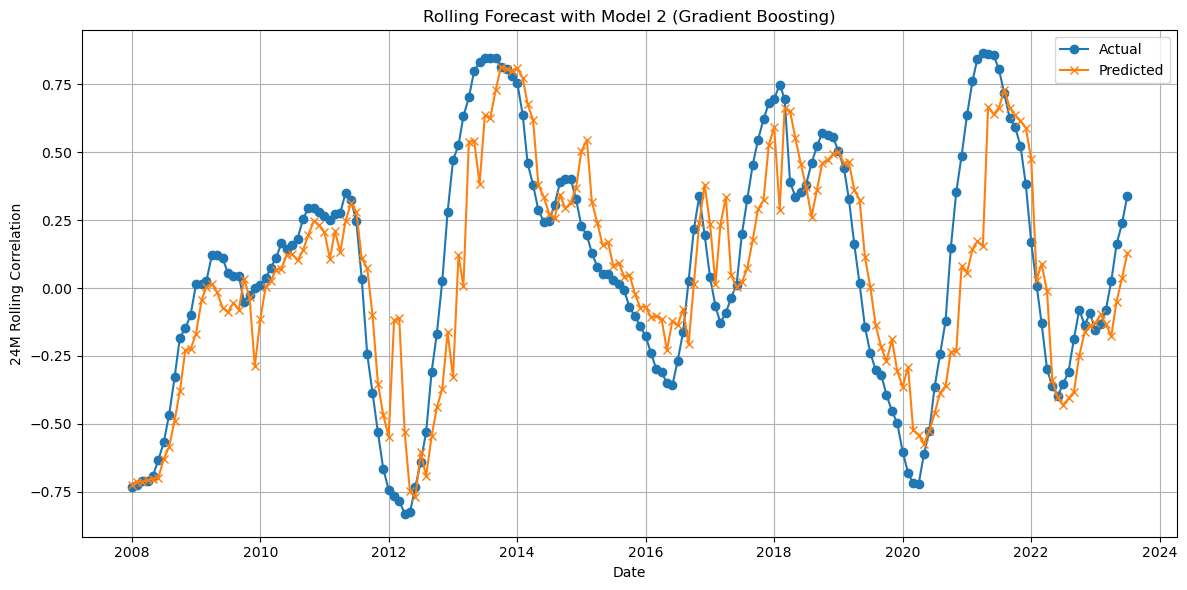

In [19]:
# --- Data Setup ---
features = [
    'Inflation_10y',
    'Inflation_Uncertainty_10y',
    'Real_Yield_10y',
    'VIX',
    'INDPRO_YoY_Growth'
]
target = 'SP500_TLT_Corr_24m_fl'

df = macro_fl_df.dropna().copy()

# --- Rolling Forecast ---
initial_train_size = 60
actuals, predictions, dates = [], [], []

for i in range(initial_train_size, len(df) - 1):
    train = df.iloc[:i]
    test = df.iloc[i:i+1]

    model = GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.01,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )
    model.fit(train[features], train[target])
    pred = model.predict(test[features])

    actuals.append(test[target].values[0])
    predictions.append(pred[0])
    dates.append(test.index[0])

# --- REGRESSION METRICS ---
# --- Fisher Z-transform ---
def fisher_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

# --- Direction Helper ---
def get_direction(series):
    return [1 if j - i > 0 else 0 for i, j in zip(series[:-1], series[1:])]

# RMSE
rmse = np.sqrt(mean_squared_error(actuals, predictions))

# Fisher z-RMSE (for correlation targets)
z_actuals = [fisher_z(x) for x in actuals]
z_predictions = [fisher_z(x) for x in predictions]
z_rmse = np.sqrt(mean_squared_error(z_actuals, z_predictions))

# MAE
mae = mean_absolute_error(actuals, predictions)

# Pearson r
pearson_r, _ = pearsonr(actuals, predictions)

# --- DIRECTIONAL METRICS ---
actual_directions = get_direction(actuals)
predicted_directions = get_direction(predictions)
trend_acc = accuracy_score(actual_directions, predicted_directions)
f1 = f1_score(actual_directions, predicted_directions)

# --- PRINT METRICS ---
print(f"RMSE: {rmse:.4f}")
print(f"Fisher z-RMSE: {z_rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Pearson r: {pearson_r:.4f}")
print(f"Trend Accuracy: {trend_acc:.2%}")
print(f"F1 Score (Direction): {f1:.2f}")

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
print(confusion_matrix(actual_directions, predicted_directions))

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(actual_directions, predicted_directions, target_names=["Down", "Up"]))

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.plot(dates, actuals, label='Actual', marker='o')
plt.plot(dates, predictions, label='Predicted', marker='x')
plt.title('Rolling Forecast with Model 2 (Gradient Boosting)')
plt.xlabel('Date')
plt.ylabel('24M Rolling Correlation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

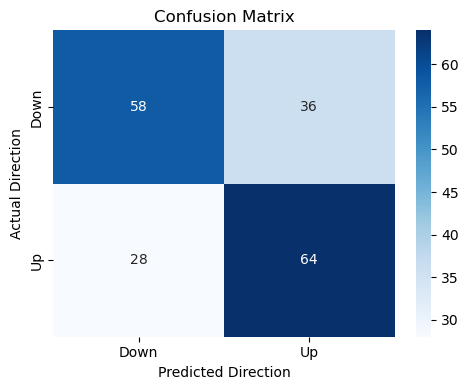

Classification Report (F1, Precision, Recall):


,precision,recall,f1-score,support
Down,0.67,0.62,0.64,94.00
Up,0.64,0.70,0.67,92.00
accuracy,0.66,0.66,0.66,0.66
macro avg,0.66,0.66,0.66,186.00
weighted avg,0.66,0.66,0.66,186.00


In [23]:
# --- Prepare Inputs ---
y_true = actual_directions
y_pred = predicted_directions
labels = ["Down", "Up"]

# --- Confusion Matrix as Heatmap ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Direction")
plt.ylabel("Actual Direction")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# --- Classification Report as DataFrame ---
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=labels,
    output_dict=True,
    zero_division=0  # Prevent warnings if any class is not predicted
)

report_df = pd.DataFrame(report_dict).transpose().round(2)

# --- Show as Table ---
print("Classification Report (F1, Precision, Recall):")
display(report_df)

---

# Rolling Forecast: Hyperparameter Comparison Using Gradient Boosting

This notebook documents and compares the performance of two Gradient Boosting Regressor configurations for forecasting the **24-month forward-looking rolling correlation** between the **S&P 500** and **TLT** using macroeconomic indicators. The objective is to evaluate the impact of hyperparameter tuning—specifically `max_depth` and `subsample`—on model accuracy and generalization.

---

## Model Configurations
```python
model = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
```
Both models share the same `n_estimators` and `learning_rate`, ensuring that only `max_depth` and `subsample` vary to isolate their effects.

---

## Observations & Insights

- Deeper trees (`max_depth=5`) allowed the model to capture more complex, nonlinear interactions.  
- `subsample < 1.0` (i.e. bagging) introduced controlled randomness, reducing overfitting and improving stability.  
- Model 2’s combination of expressiveness (deeper trees) and regularization (bagging) outperformed Model 1 on all key fronts.  
- Even with the same `learning_rate` and `n_estimators`, small structural changes can lead to substantial performance gains in time-series regression.

---

## Model 2 Evaluation Summary

This cell provides an in-depth performance assessment of Model 2, including regression metrics, classification-based trend evaluation, and visual forecast analysis.

---

### Regression Performance

| Metric              | Value     | Interpretation |
|---------------------|-----------|----------------|
| **RMSE**            | 0.2268    | Reflects the average absolute prediction error in the same unit as the target (correlation). A relatively low RMSE here suggests the model is making accurate point estimates. The improvement over Model 1 (0.2618) confirms better fit and reduced noise sensitivity. RMSE is scale-dependent but reliable for comparison between models trained on the same data and target. |
| **MAPE**            | 238.88%   | Very high—this stems from the denominator in the MAPE formula, which becomes unstable when actual correlation values approach zero. Since stock-bond correlations are mean-reverting and often hover near zero, percentage-based errors can become inflated even for small absolute deviations. This limits interpretability and makes MAPE an unreliable performance metric in this use case, though such behavior is expected when modeling correlation-based targets. |
| **Trend Accuracy**  | 65.59%    | Indicates that the model correctly predicts the direction of change (up or down) in approximately two-thirds of cases. This is crucial for financial applications like asset allocation or hedging, where anticipating turning points or regime shifts matters more than precise values. The strong directional capture complements the RMSE result and supports the model’s practical relevance. |

> **RMSE is valid**, while **MAPE is misleading** due to small denominator effects. **Trend accuracy provides complementary directional insight**.

---

### Classification-Based Trend Evaluation

We binarized the target direction (up = 1, down = 0) and computed classification metrics:

#### Confusion Matrix
	• True Positives (Up predicted as Up): 64
	• True Negatives (Down predicted as Down): 58
	• False Positives (Down predicted as Up): 36
	• False Negatives (Up predicted as Down): 28

#### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| **Down** | 0.67 | 0.62 | 0.64 | 94 |
| **Up**   | 0.64 | 0.70 | 0.67 | 92 |
| **Accuracy** | | | **0.66** | 186 |

> Balanced performance across both classes. The model is equally good at predicting rising and falling correlations, with overall **66% accuracy** and consistent **F1-scores**.

---

### Visual Fit Assessment

The prediction curve (orange) closely follows the actual curve (blue), with:

- Accurate tracking of **long-term trends** and **macro inflection points** (e.g., 2010, 2016, 2020)
- Less **lag at turning points** compared to earlier models
- Smoothed predictions due to subsampling (`subsample=0.8`), reducing short-term noise

> Model 2 provides a **stable and generalizable fit** suitable for rolling-forecast frameworks and practical decision support.

---

### Final Takeaways

- RMSE and classification metrics show **Model 2’s superiority over Model 1**
- Visual fit confirms its ability to **respect regime shifts**
- Trend-based evaluation using **confusion matrix** and **F1-score** adds further robustness to your claim

---

### Recommendation

Model 2 (`max_depth=5`, `subsample=0.8`) should be adopted as the baseline configuration going forward, especially when integrating Beige Book sentiment and regime classification in the next phase of your forecasting pipeline.

In [25]:
validation_start_date = macro_fl_df.index[initial_train_size]
print(f"Validation phase starts at: {validation_start_date.strftime('%Y-%m')}")

Validation phase starts at: 2008-01


In [27]:
initial_train_size = 60

for i in range(initial_train_size, initial_train_size + 5):
    feature_date = macro_fl_df.index[i]
    start = (feature_date + pd.DateOffset(months=1)).date()  # 1 month after feature
    end = (feature_date + pd.DateOffset(months=24)).date()   # 24-month window
    print(f"Features at: {feature_date.date()}, Target represents 24M rolling correlation from: {start} to {end}")

Features at: 2008-01-01, Target represents 24M rolling correlation from: 2008-02-01 to 2010-01-01
Features at: 2008-02-01, Target represents 24M rolling correlation from: 2008-03-01 to 2010-02-01
Features at: 2008-03-01, Target represents 24M rolling correlation from: 2008-04-01 to 2010-03-01
Features at: 2008-04-01, Target represents 24M rolling correlation from: 2008-05-01 to 2010-04-01
Features at: 2008-05-01, Target represents 24M rolling correlation from: 2008-06-01 to 2010-05-01


In [11]:
# --- Data Setup ---
features = [
    'Inflation_10y',
    'Inflation_Uncertainty_10y',
    'Real_Yield_10y',
    'VIX',
    'INDPRO_YoY_Growth'
]
target = 'SP500_TLT_Corr_24m_fl'

df = macro_fl_df.dropna().copy()

In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, f1_score, accuracy_score,
    confusion_matrix, classification_report
)
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Fisher Z-transform ---
def fisher_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

# --- Direction Helper ---
def get_direction(series):
    return [1 if j - i > 0 else 0 for i, j in zip(series[:-1], series[1:])]

def run_xgb_forecast(df, features, target, params, model_name="XGB"):
    initial_train_size = 60
    actuals, predictions, dates = [], [], []

    for i in range(initial_train_size, len(df) - 1):
        train = df.iloc[:i]
        test  = df.iloc[i:i+1]

        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            **params
        )
        model.fit(train[features], train[target])
        pred = model.predict(test[features])

        actuals.append(test[target].values[0])
        predictions.append(pred[0])
        dates.append(test.index[0])

    # --- Convert to arrays ---
    y_true = np.asarray(actuals, dtype=float)
    y_pred = np.asarray(predictions, dtype=float)

    # --- Regression Metrics ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    z_rmse = np.sqrt(mean_squared_error([fisher_z(x) for x in y_true],
                                        [fisher_z(x) for x in y_pred]))
    r_val, r_p = pearsonr(y_true, y_pred)

    # --- Directional Metrics ---
    actual_directions = get_direction(y_true)
    predicted_directions = get_direction(y_pred)
    trend_acc = accuracy_score(actual_directions, predicted_directions)
    f1 = f1_score(actual_directions, predicted_directions)

    return {
        "Model": model_name,
        "Params": params,
        "RMSE": rmse,
        "MAE": mae,
        "Fisher_z_RMSE": z_rmse,
        "Pearson_r": r_val,
        "Trend_Acc": trend_acc,
        "F1_Dir": f1
    }

# --- Define hyperparameter sets for comparison ---
xgb_param_sets = [
    {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8},
    {"n_estimators": 400, "learning_rate": 0.01, "max_depth": 4, "subsample": 0.8},
    {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 5, "subsample": 0.9},
    {"n_estimators": 400, "learning_rate": 0.01, "max_depth": 5, "subsample": 0.9}
]

# --- Run experiments ---
summary = []
for i, params in enumerate(xgb_param_sets, 1):
    print("="*60)
    print(f"Running XGBoost Config {i} with params: {params}")
    result = run_xgb_forecast(df, features, target, params, model_name=f"XGB Config {i}")
    summary.append(result)

# --- Collect into DataFrame ---
summary_df = pd.DataFrame(summary)
summary_df = summary_df.round(4)
display(summary_df)

# --- Optional: highlight best ---
styled = summary_df.style.highlight_min(
    subset=["RMSE", "MAE", "Fisher_z_RMSE"], color="lightgreen"
).highlight_max(
    subset=["Pearson_r", "Trend_Acc", "F1_Dir"], color="lightblue"
)
styled

Running XGBoost Config 1 with params: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8}
Running XGBoost Config 2 with params: {'n_estimators': 400, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.8}
Running XGBoost Config 3 with params: {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.9}
Running XGBoost Config 4 with params: {'n_estimators': 400, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 0.9}


,Model,Params,RMSE,MAE,Fisher_z_RMSE,Pearson_r,Trend_Acc,F1_Dir
0,XGB Config 1,"{'n_estimators': 400, 'learning_rate': 0.05, '...",0.2259,0.1695,0.3023,0.8583,0.6129,0.6250
1,XGB Config 2,"{'n_estimators': 400, 'learning_rate': 0.01, '...",0.2469,0.1894,0.3268,0.8276,0.6129,0.6170
2,XGB Config 3,"{'n_estimators': 400, 'learning_rate': 0.05, '...",0.2289,0.1687,0.3035,0.8543,0.6183,0.6283
3,XGB Config 4,"{'n_estimators': 400, 'learning_rate': 0.01, '...",0.2425,0.1824,0.3202,0.8341,0.6075,0.6096


,Model,Params,RMSE,MAE,Fisher_z_RMSE,Pearson_r,Trend_Acc,F1_Dir
0,XGB Config 1,"{'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8}",0.225900,0.169500,0.302300,0.858300,0.612900,0.625000
1,XGB Config 2,"{'n_estimators': 400, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.8}",0.246900,0.189400,0.326800,0.827600,0.612900,0.617000
2,XGB Config 3,"{'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.9}",0.228900,0.168700,0.303500,0.854300,0.618300,0.628300
3,XGB Config 4,"{'n_estimators': 400, 'learning_rate': 0.01, 'max_depth': 5, 'subsample': 0.9}",0.242500,0.182400,0.320200,0.834100,0.607500,0.609600


## Testing with backward looking data - not right approach

In [12]:
# # Read the CSV into a DataFrame
# macro_bl_path = os.path.join(macro_directory, "macro_final_bl_df.csv")
# macro_bl_df = pd.read_csv(macro_bl_path, index_col=0, parse_dates=True)

# # Confirm successful load
# print(macro_bl_df.info())
# print(macro_bl_df.head(2))
# print(macro_bl_df.tail(2))

In [14]:
# # === Configuration ===
# features = [
#     'Inflation_10y',
#     'Inflation_Uncertainty_10y',
#     'Real_Yield_10y',
#     'VIX',
#     'INDPRO_YoY_Growth'
# ]

# target = 'SP500_TLT_Corr_24m_bl'
# initial_train_size = 60  # 5 years minimum
# n_search_iter = 10       # Number of random parameter combinations to try

# df = macro_bl_df.dropna().copy()

# # === Storage for rolling forecast ===
# actuals = []
# predictions = []
# dates = []

# # === Rolling Forecast with RandomizedSearch ===
# for i in range(initial_train_size, len(df) - 1):
#     train = df.iloc[:i]
#     test = df.iloc[i:i+1]

#     X_train = train[features]
#     y_train = train[target]
#     X_test = test[features]
#     y_test = test[target]

#     pipeline = Pipeline([
#         ('scaler', StandardScaler()),
#         ('regressor', GradientBoostingRegressor(random_state=42))
#     ])

#     param_dist = {
#         'regressor__n_estimators': [50, 100, 200, 300],
#         'regressor__learning_rate': [0.01, 0.05, 0.1],
#         'regressor__max_depth': [2, 3, 4],
#         'regressor__subsample': [0.8, 0.9, 1.0]
#     }

#     search = RandomizedSearchCV(
#         estimator=pipeline,
#         param_distributions=param_dist,
#         n_iter=n_search_iter,
#         scoring='neg_mean_squared_error',
#         cv=3,
#         n_jobs=-1,
#         random_state=42
#     )

#     search.fit(X_train, y_train)
#     best_model = search.best_estimator_

#     y_pred = best_model.predict(X_test)

#     actuals.append(y_test.values[0])
#     predictions.append(y_pred[0])
#     dates.append(test.index[0])

# # === Evaluation ===
# rmse = np.sqrt(mean_squared_error(actuals, predictions))
# print(f"Rolling Forecast RMSE: {rmse:.4f}")

# # === Plot Results ===
# plt.figure(figsize=(12, 6))
# plt.plot(dates, actuals, label='Actual', marker='o')
# plt.plot(dates, predictions, label='Predicted', marker='x')
# plt.title('Rolling Forecast (Wu-style Baseline + RandomizedSearchCV)')
# plt.xlabel('Date')
# plt.ylabel('24M Rolling Correlation')
# plt.legend()
# plt.grid(True)
# plt.show()

In [16]:
# # Manual Selection of hyperparameters
# features = [
#     'Inflation_10y',
#     'Inflation_Uncertainty_10y',
#     'Real_Yield_10y',
#     'VIX',
#     'INDPRO_YoY_Growth'
# ]
# target = 'SP500_TLT_Corr_24m_bl'

# # Drop NA
# df = macro_bl_df.dropna().copy()

# # Rolling forecast setup
# initial_train_size = 60
# actuals, predictions, dates = [], [], []

# for i in range(initial_train_size, len(df) - 1):
#     train = df.iloc[:i]
#     test = df.iloc[i:i+1]

#     model = GradientBoostingRegressor(
#         n_estimators=400,       # Try boosting trees a bit more
#         learning_rate=0.01,
#         max_depth=4,            # Slightly deeper trees
#         subsample=1.0,
#         random_state=42
#     )
#     model.fit(train[features], train[target])
#     pred = model.predict(test[features])

#     actuals.append(test[target].values[0])
#     predictions.append(pred[0])
#     dates.append(test.index[0])

# rmse = np.sqrt(mean_squared_error(actuals, predictions))
# print(f"Rolling Forecast RMSE: {rmse:.4f}")

# # Plot
# plt.figure(figsize=(12, 6))
# plt.plot(dates, actuals, label='Actual', marker='o')
# plt.plot(dates, predictions, label='Predicted', marker='x')
# plt.title('Rolling Forecast (Wu-style Baseline)')
# plt.xlabel('Date')
# plt.ylabel('24M Rolling Correlation')
# plt.legend()
# plt.grid(True)
# plt.show()